In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


Dataset Classes

In [4]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Dataset Images Show

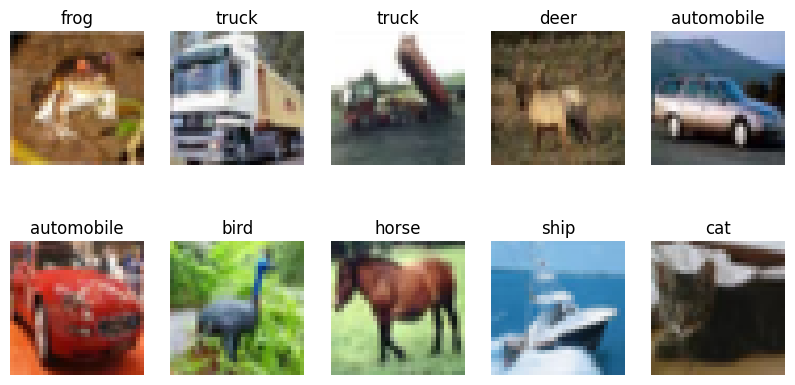

In [6]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

Images Normalize

In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0

Labels Convert (Categorical)

In [8]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Train / Validation Split

In [9]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42)

print("Training:", x_train.shape)
print("Validation:", x_val.shape)

Training: (40000, 32, 32, 3)
Validation: (10000, 32, 32, 3)


In [11]:
from tensorflow.keras import layers, models

CNN Model Create

In [12]:
model = models.Sequential()

In [14]:
model = models.Sequential()

model.add(layers.Input(shape=(32,32,3)))

model.add(layers.Conv2D(32,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [17]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_val, y_val)
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 69s 53ms/step - accuracy: 0.3393 - loss: 1.7870 - val_accuracy: 0.5344 - val_loss: 1.2979
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.5592 - loss: 1.2440 - val_accuracy: 0.6046 - val_loss: 1.1120
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 52ms/step - accuracy: 0.6275 - loss: 1.0534 - val_accuracy: 0.6309 - val_loss: 1.0532
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 52ms/step - accuracy: 0.6740 - loss: 0.9230 - val_accuracy: 0.6602 - val_loss: 0.9862
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - accuracy: 0.7077 - loss: 0.8312 - val_accuracy: 0.6659 - val_loss: 0.9520
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - accuracy: 0.7331 - loss: 0.7626 - val_accuracy: 0.6893 - val_loss: 0.9129
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 68s 54ms/step - accuracy: 0.7610 - loss: 0.6925 - val_accuracy: 0.6948 - val_loss: 0.8871
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - accuracy: 0.7787 -

In [18]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7166 - loss: 0.8970
Test Accuracy: 0.713100016117096


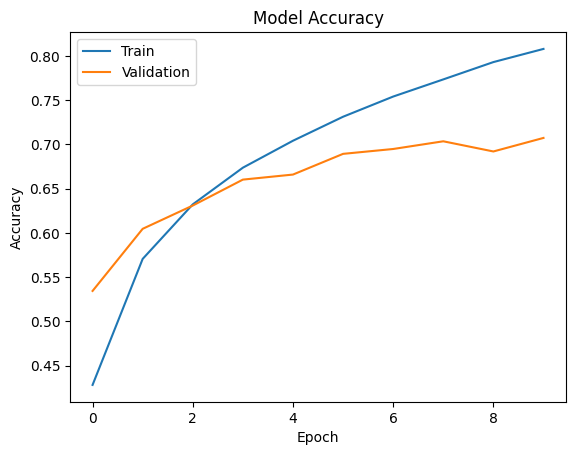

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

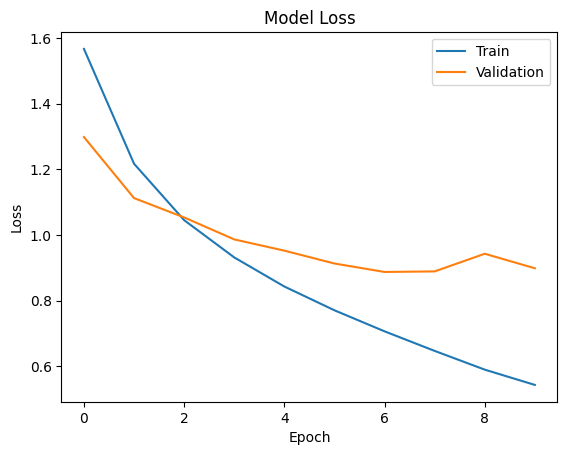

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

In [21]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

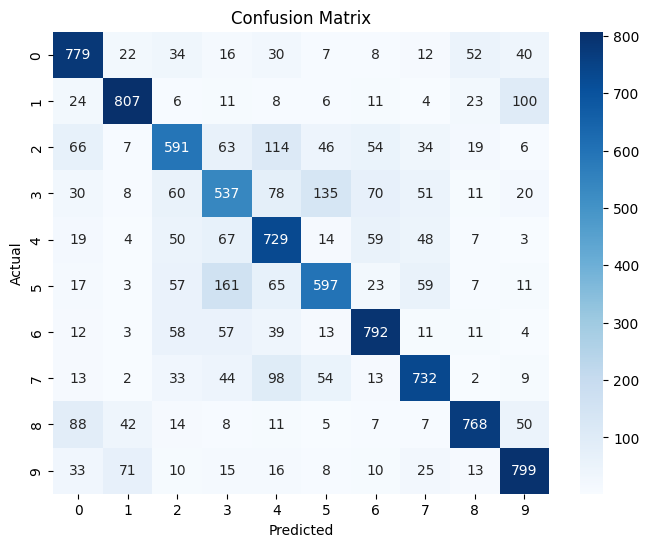

In [23]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [24]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.72      0.78      0.75      1000
           1       0.83      0.81      0.82      1000
           2       0.65      0.59      0.62      1000
           3       0.55      0.54      0.54      1000
           4       0.61      0.73      0.67      1000
           5       0.67      0.60      0.63      1000
           6       0.76      0.79      0.77      1000
           7       0.74      0.73      0.74      1000
           8       0.84      0.77      0.80      1000
           9       0.77      0.80      0.78      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



Transfer Learning using a pretrained CNN

In [25]:
from tensorflow.keras.applications import MobileNetV2

In [26]:
base_model = MobileNetV2(
    input_shape=(32,32,3),
    include_top=False,
    weights='imagenet'
)

/tmp/ipykernel_287/2778595956.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
base_model.trainable = False

In [28]:
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [30]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
transfer_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
history_transfer = transfer_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_val, y_val)
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - accuracy: 0.3557 - loss: 1.7811 - val_accuracy: 0.3389 - val_loss: 1.8162
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 51ms/step - accuracy: 0.3668 - loss: 1.7496 - val_accuracy: 0.3454 - val_loss: 1.8018
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.3732 - loss: 1.7265 - val_accuracy: 0.3453 - val_loss: 1.8023
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - accuracy: 0.3848 - loss: 1.7040 - val_accuracy: 0.3490 - val_loss: 1.7981
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.3903 - loss: 1.6905 - val_accuracy: 0.3487 - val_loss: 1.8029
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - accuracy: 0.3943 - loss: 1.6797 - val_accuracy: 0.3501 - val_loss: 1.7972
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 51ms/step - accuracy: 0.4020 - loss: 1.6654 - val_accuracy: 0.3485 - val_loss: 1.7975
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 50ms/step - accuracy: 0.4036 -

In [34]:
test_loss, test_acc = transfer_model.evaluate(x_test, y_test)

print("Transfer Learning Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.3598 - loss: 1.8123
Transfer Learning Accuracy: 0.3555000126361847
